# **Weathering mediated bedrock erosion: Application**

### Preliminaries

In [1]:
from essentials import *

In [2]:
theory = Equations()
viz = VizApplications(dpi=100,)

# Channel wall

In [3]:
physical_parameters = {
    v_r:1, 
    v_b:0.05, 
    h:1,
    z_vc:0.1, 
    kappa_v:10, 
    w_r:1.5, 
    k:1, 
    z_wc:0.1, 
    kappa_w:50
}
physical_parameters
channel_wall_highW = ChannelWallApplication(theory, physical_parameters,)
channel_wall = channel_wall_highW
channel_wall.compute_vertical_profiles(n_pts=200,)
channel_wall.compute_cross_section()

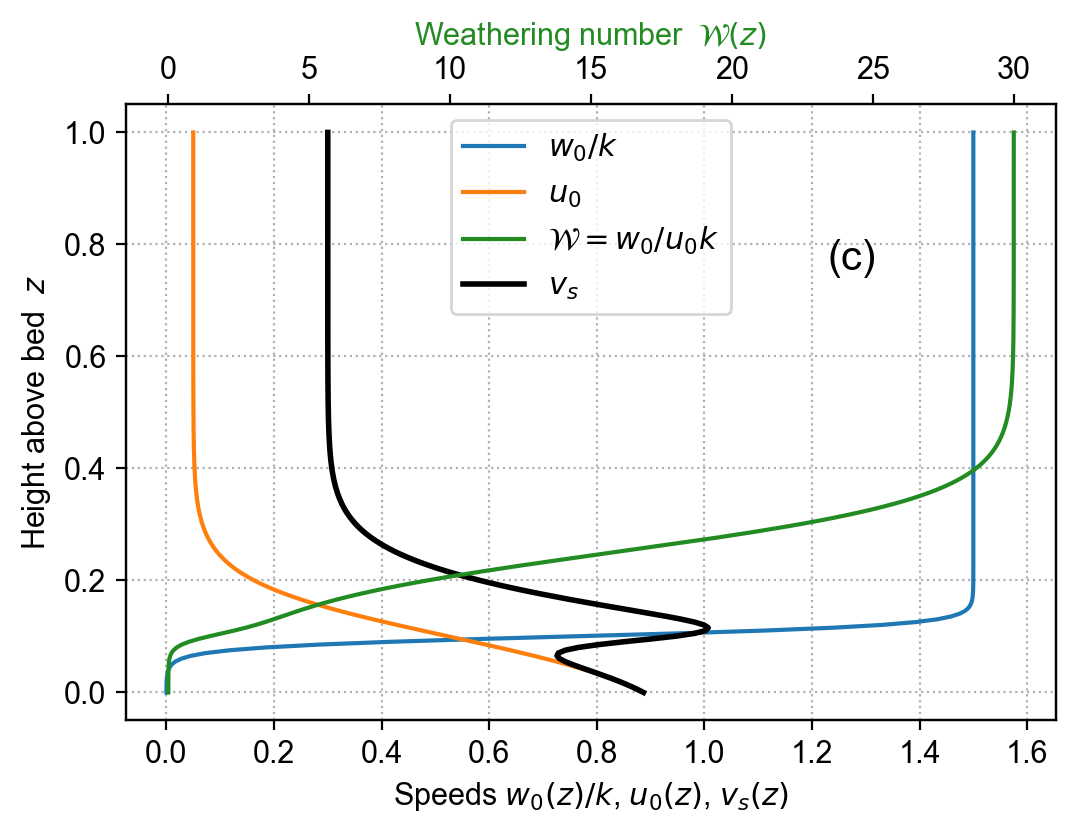

In [4]:
name = "z_w0_v0_vs_W_highW"
viz.channel_refweatheringrate_referosionrate_W(
    name, model=channel_wall_highW, text_label=((0.78,0.75),"(c)",15),
)

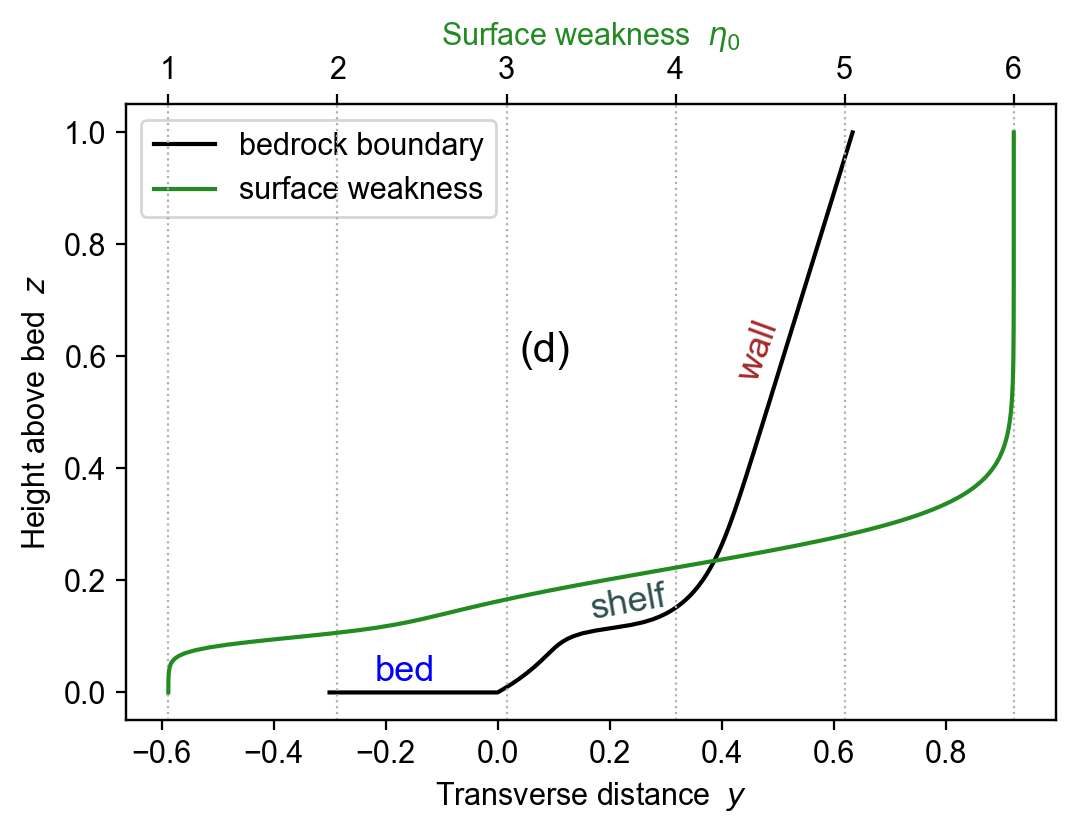

In [5]:
name = "z_y_highW"
z_label = "Height above bed  $z$"
zys = (
    (
        channel_wall_highW.ch_z_array, 
        z_label, 
        channel_wall_highW.ch_y_array,
        "Transverse distance  $y$", 
        "bedrock boundary",
    ), 
    (
        channel_wall_highW.z_array, 
        "", 
        channel_wall_highW.eta0_array,
        "Surface weakness  $\eta_0$", 
        "surface weakness",
    )
)
text_labels=(
    ((0.45,0.6), "(d)", 15, "k", 0,),
    ((0.3,0.08), "bed", 13, "b", 0,),
    ((0.54,0.19), "shelf", 13, "darkslategray", 10,),
    ((0.68,0.6), "wall", 13, "brown", 70,),
)
viz.channel_generic(
    name, zys=zys, do_equal_aspect=True, text_labels=text_labels,
)

In [6]:
physical_parameters = {
    v_r:1, 
    v_b:0.05, 
    h:1,
    z_vc:0.1, 
    kappa_v:10,
    w_r:0.11, 
    k:1, 
    z_wc:0.1, 
    kappa_w:50
}
physical_parameters
channel_wall_transW = ChannelWallApplication(theory, physical_parameters,)
channel_wall = channel_wall_transW
channel_wall.compute_vertical_profiles(n_pts=200,)
channel_wall.compute_cross_section()
# channel_wall.v0_eqn_vr_h_z
# channel_wall.w0_eqn_wr_z
# channel_wall.vs_calibrated

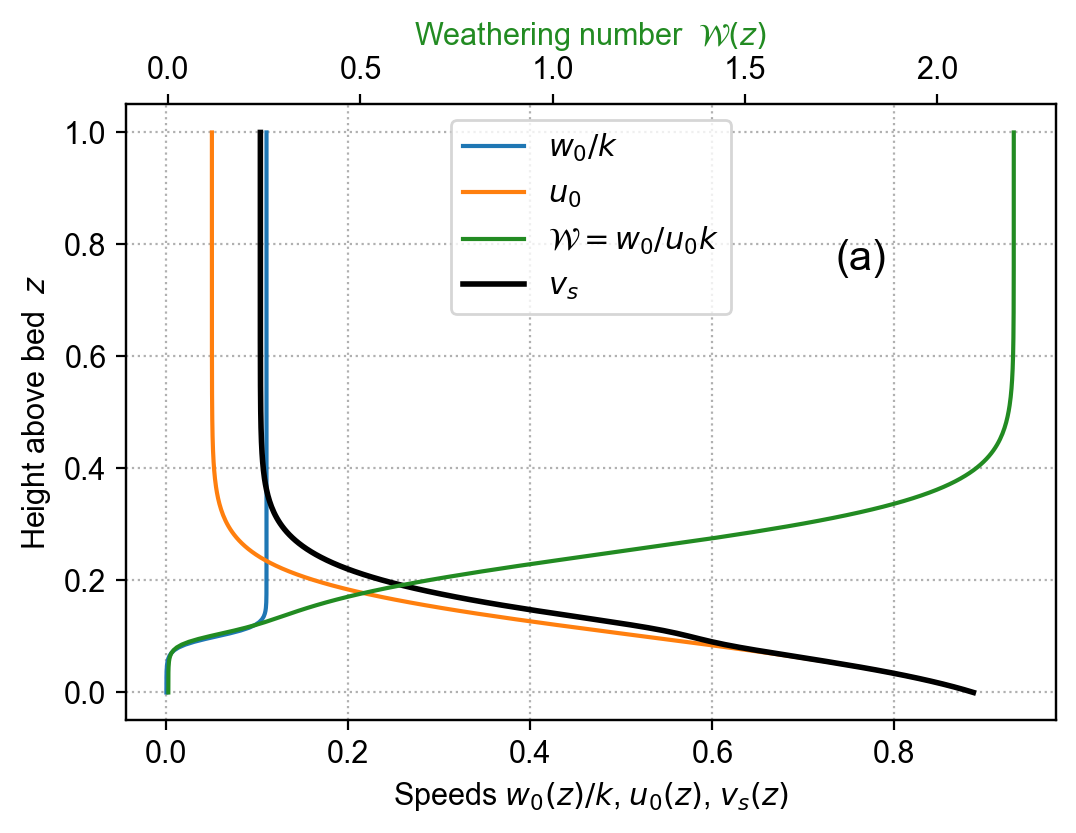

In [7]:
name = "z_w0_v0_vs_W_transW"
viz.channel_refweatheringrate_referosionrate_W(
    name, model=channel_wall_transW, text_label=((0.79,0.75),"(a)",15),
)

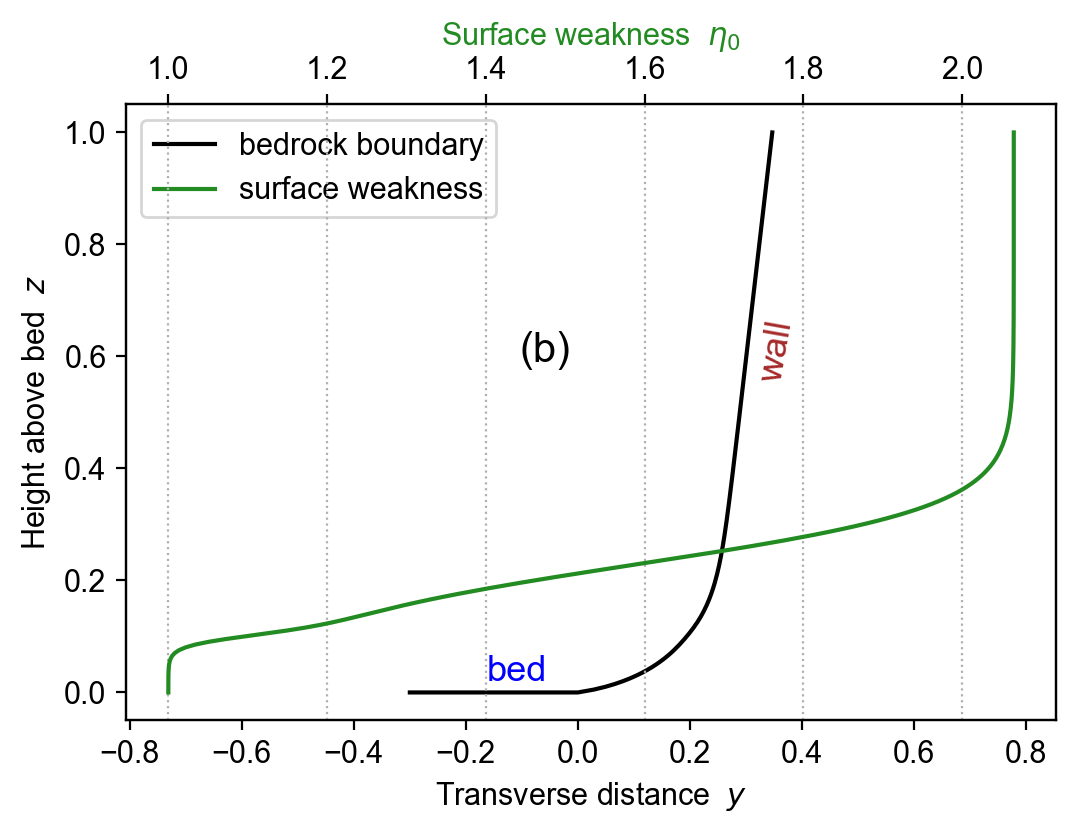

In [8]:
name = "z_y_transW"
z_label = "Height above bed  $z$"
zys = (
    (
        channel_wall_transW.ch_z_array, 
        z_label,
        channel_wall_transW.ch_y_array,
        r"Transverse distance  $y$",
        "bedrock boundary",
    ), 
    (
        channel_wall_transW.z_array, 
        "",
        channel_wall_transW.eta0_array,
        r"Surface weakness  $\eta_0$",
        "surface weakness",
    )
)
text_labels=(
    ((0.45,0.6), "(b)", 15, "k", 0,),
    ((0.42,0.08), "bed", 13,"b", 0,),
    ((0.7,0.6), "wall", 13, "brown", 80,)
)
viz.channel_generic(
    name, zys=zys, do_equal_aspect=True, text_labels=text_labels,
)


# Export

In [9]:
plots_dir: str = create_directories((os.path.curdir,), "plots",)
print(tuple(viz.fdict.keys()))
export_plots(
    viz.fdict,
    plots_dir,
    "pdf",
    suffix="",
    dpi=150,
)

('z_w0_v0_vs_W_highW', 'z_y_highW', 'z_w0_v0_vs_W_transW', 'z_y_transW')


'././plots'